<a href="https://colab.research.google.com/github/MedhatElhawy/solvingNotbooks/blob/main/Solution_week4_perceptron_logistic_DeepNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

### Exercise 1: Logistic Regression from Scratch (2 Features)

In the demo above, we used:
- Feature 0: `mean radius`
- Feature 1: `mean texture`

Now, **your turn**: Implement Logistic Regression from scratch on **2 different features**!

**Suggested feature pairs:**
1. Features [20, 21]: `worst radius` + `worst texture`
2. Features [0, 2]: `mean radius` + `mean perimeter`
3. Features [7, 27]: `mean area` + `worst area`
4. Any two features of your choice!

**Your task:**
1. Select 2 features
2. Prepare and normalize the data
3. Implement the **full training loop** (gradient descent with sigmoid)
4. Evaluate train and test accuracy
5. Visualize the decision boundary with probability heatmap

Libraries loaded successfully!


/tmp/ipython-input-3802463976.py:98: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(X_train_scaled[y_train == 0, 0], X_train_scaled[y_train == 0, 1],


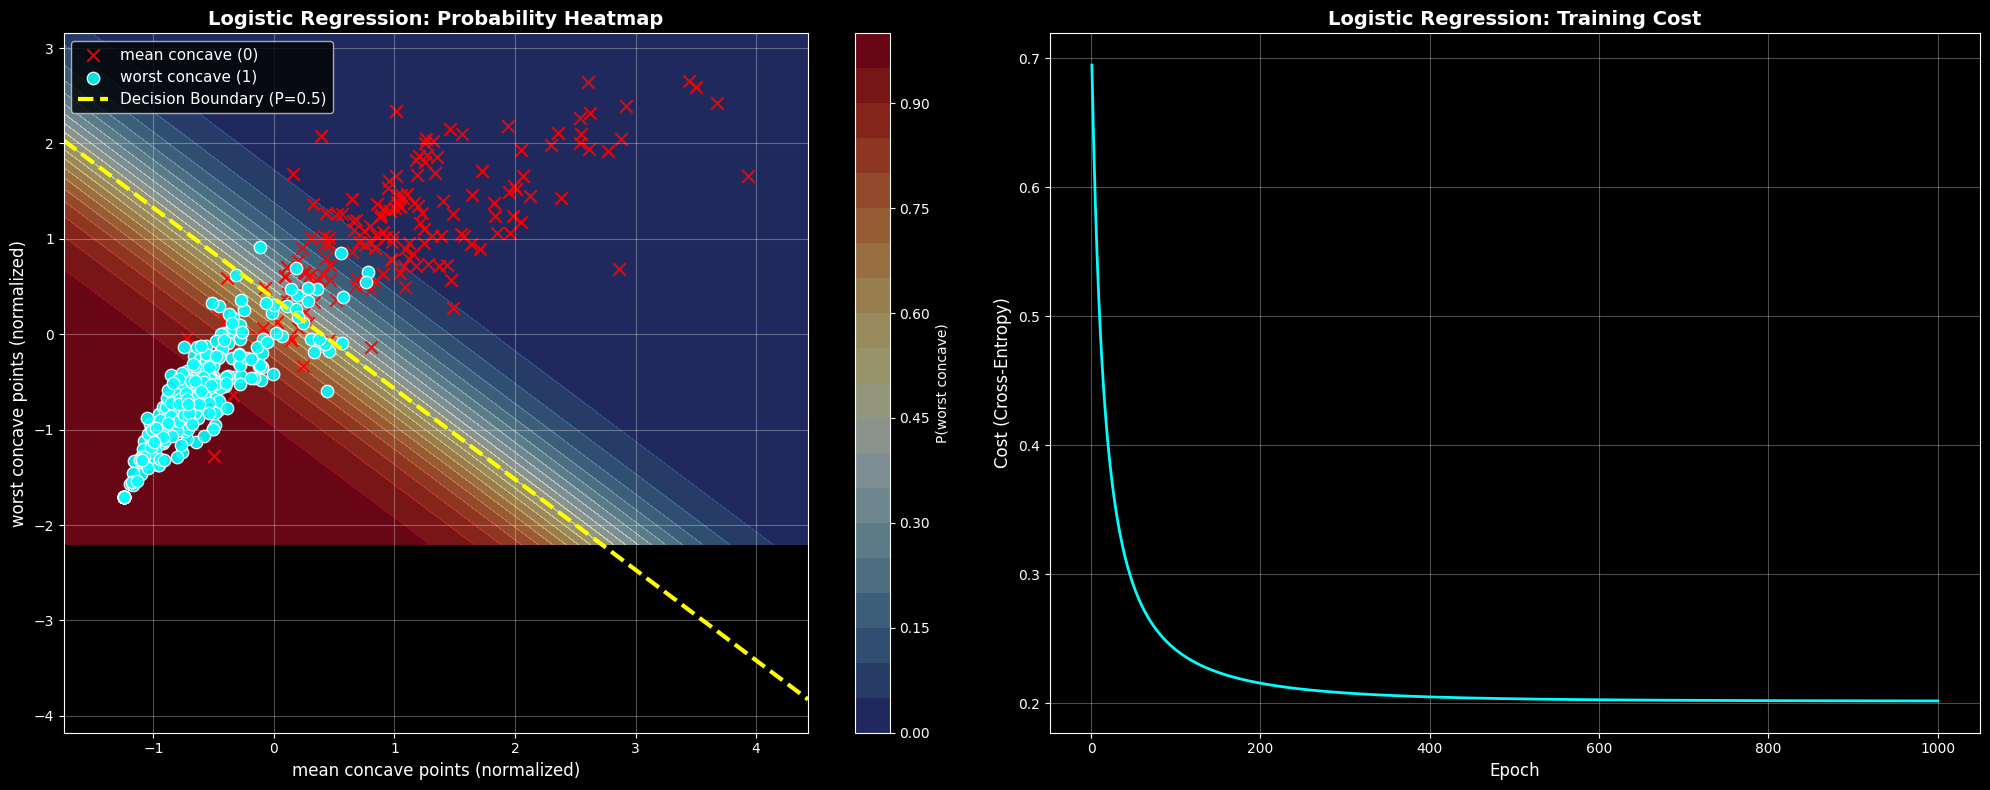

Notice: The heatmap shows probability!
  Red regions: High probability of mean concave (P(worst concave) close to 0)
  Blue regions: High probability of worst concave (P(worst concave) close to 1)
  Yellow line: Decision boundary (P(worst concave) = 0.5)
EXERCISE 1: LOGISTIC REGRESSION FROM SCRATCH
Features: mean concave points
          worst concave points

Training Accuracy: 92.31%
Testing Accuracy:  92.98%
Final Cost: 0.201895


In [1]:
# Exercise 1: Logistic Regression from Scratch

# YOUR CODE HERE
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Use dark background theme
plt.style.use('dark_background')

print("Libraries loaded successfully!")

# Load the dataset
data = load_breast_cancer()

#Select 2 features
ex1_feature_indices = [7, 27]
x = data.data[:, ex1_feature_indices]
y = data.target

#Prepare and normalize the data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_bias = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
X_test_bias = np.column_stack([np.ones(X_test_scaled.shape[0]), X_test_scaled])

#Implement the full training loop (gradient descent with sigmoid)
np.random.seed(42)
w_logistic = np.random.randn(3) * 0.01
epochs = 1000
lr = 0.1
cost_ex1 = np.zeros(epochs)
for epoch in range(epochs):
    # Forward pass
    z =  X_train_bias @ w_logistic
    h = 1 / (1 + np.exp(-z))

    # Compute error
    error  = h - y_train

    # Update weights using gradient descent
    w_logistic -= lr * (X_train_bias.T @ error) / len(X_train_scaled)


    # Compute cost (Cross-Entropy)
    cost_ex1[epoch] = -np.mean(
        y_train * np.log(h + 1e-10) + (1 - y_train) * np.log(1 - h + 1e-10)
    )

    # Early stopping if cost is very low
    if cost_ex1[epoch] < 1e-6:
        print(f"Converged at epoch {epoch + 1}!")
        break

b_logistic = w_logistic[0]
w1_logistic = w_logistic[1]
w2_logistic = w_logistic[2]

#Evaluate train and test accuracy
# Training accuracy
train_probs = 1 / (1 + np.exp(-(X_train_bias @ w_logistic)))
train_predictions_logistic = np.where(train_probs >= 0.5, 1, 0)
train_acc_ex1 = np.mean(train_predictions_logistic == y_train) * 100

# Testing accuracy
test_probs = 1 / (1 + np.exp(-(X_test_bias @ w_logistic)))
test_predictions_logistic = np.where(test_probs >= 0.5, 1, 0)
test_acc_ex1 = np.mean(test_predictions_logistic == y_test) * 100


#Visualize the decision boundary with probability heatmap

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), dpi=100)

# Create a mesh grid for probability heatmap
x1_grid = np.linspace(X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5, 200)
x2_grid = np.linspace(X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5, 200)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([np.ones(X1_mesh.ravel().shape[0]), X1_mesh.ravel(), X2_mesh.ravel()])

# Compute probabilities for all grid points
z_grid = X_grid @ w_logistic
prob_grid = 1 / (1 + np.exp(-z_grid))

# Plot 1: Decision boundary with probability heatmap
contour = ax1.contourf(X1_mesh, X2_mesh, prob_grid.reshape(X1_mesh.shape),
                       levels=20, cmap='RdYlBu_r', alpha=0.6)
plt.colorbar(contour, ax=ax1, label='P(worst concave)')

ax1.scatter(X_train_scaled[y_train == 0, 0], X_train_scaled[y_train == 0, 1],
            c='red', s=80, marker='x', label='mean concave (0)',
            edgecolors='white', linewidth=1.5, alpha=0.9)
ax1.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1],
            c='cyan', s=80, marker='o', label='worst concave (1)',
            edgecolors='white', linewidth=1, alpha=0.9)

# Plot decision boundary (where probability = 0.5)
x1_vals = np.linspace(X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5, 100)
x2_vals = -(w1_logistic * x1_vals + b_logistic) / w2_logistic
ax1.plot(x1_vals, x2_vals, 'yellow', linewidth=3, label='Decision Boundary (P=0.5)', linestyle='--')

ax1.set_xlabel(data.feature_names[ex1_feature_indices[0]] + ' (normalized)', fontsize=12)
ax1.set_ylabel(data.feature_names[ex1_feature_indices[1]] + ' (normalized)', fontsize=12)
ax1.set_title('Logistic Regression: Probability Heatmap', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Cost over epochs
ax2.plot(range(1, epoch + 2), cost_ex1[:epoch + 1], 'cyan', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Cost (Cross-Entropy)', fontsize=12)
ax2.set_title('Logistic Regression: Training Cost', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: The heatmap shows probability!")
print("  Red regions: High probability of mean concave (P(worst concave) close to 0)")
print("  Blue regions: High probability of worst concave (P(worst concave) close to 1)")
print("  Yellow line: Decision boundary (P(worst concave) = 0.5)")
print("="*70)
print("EXERCISE 1: LOGISTIC REGRESSION FROM SCRATCH")
print("="*70)
print(f"Features: {data.feature_names[ex1_feature_indices[0]]}")
print(f"          {data.feature_names[ex1_feature_indices[1]]}")
print(f"\nTraining Accuracy: {train_acc_ex1:.2f}%")
print(f"Testing Accuracy:  {test_acc_ex1:.2f}%")
print(f"Final Cost: {cost_ex1[-1]:.6f}")
print("="*70)

---

### Exercise 2: Deep Neural Network with ALL Features (PyTorch)

Now it's time to build a **powerful deep network** using **ALL 30 features**!

**Architecture:**
- **Input Layer:** 30 features (all tumor measurements!)
- **Hidden Layer 1:** 8 neurons with ReLU
- **Hidden Layer 2:** 6 neurons with ReLU
- **Hidden Layer 3:** 4 neurons with ReLU
- **Output Layer:** 1 neuron with Sigmoid

**Total:** Input(30) → Hidden1(8, ReLU) → Hidden2(6, ReLU) → Hidden3(4, ReLU) → Output(1, Sigmoid)

**Your task:**
1. Prepare data with ALL 30 features
2. Define the neural network class with the architecture above
3. Train the network
4. Evaluate accuracy
5. Compare with Exercise 1 results

**Hint:** This network has MORE information (30 features vs 2) and MORE capacity (deeper layers). Expect better accuracy!

In [2]:
# Exercise 2: Deep Neural Network with ALL 30 Features

# YOUR CODE HERE
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim

#Select 2 features
x = data.data
y = data.target

#Prepare and normalize the data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_torch = torch.FloatTensor(X_train_scaled)
y_train_torch = torch.FloatTensor(y_train).unsqueeze(1)
X_test_torch = torch.FloatTensor(X_test_scaled)
y_test_torch = torch.FloatTensor(y_test).unsqueeze(1)

class DeepNeuralNetwork(nn.Module):
  def __init__(self):
    super(DeepNeuralNetwork, self).__init__()
    self.fc1 = nn.Linear(30, 8)
    self.fc2 = nn.Linear(8, 6)
    self.fc3 = nn.Linear(6,4)
    self.fc4 = nn.Linear(4, 1)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.relu(self.fc3(x))
    x = self.sigmoid(self.fc4(x))
    return x

# Initialize model
torch.manual_seed(42)
model_ex2 = DeepNeuralNetwork()

# Count parameters
total_params_ex2 = sum(p.numel() for p in model_ex2.parameters())

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model_ex2.parameters(), lr=0.001)

# Training loop
epochs_dnn = 2000
cost_ex2 = []

for epoch in range(epochs_dnn):
    # Forward pass
    outputs = model_ex2(X_train_torch)
    loss = criterion(outputs, y_train_torch)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()  # Backpropagation through all layers!
    optimizer.step()

    cost_ex2.append(loss.item())

    if loss.item() < 1e-6:
        print(f"Converged at epoch {epoch + 1}!")
        break

with torch.no_grad():
    train_probs_dnn = model_ex2(X_train_torch).numpy()
    train_preds_dnn = (train_probs_dnn >= 0.5).astype(int).flatten()
    train_acc_ex2 = np.mean(train_preds_dnn == y_train) * 100

    test_probs_dnn = model_ex2(X_test_torch).numpy()
    test_preds_dnn = (test_probs_dnn >= 0.5).astype(int).flatten()
    test_acc_ex2 = np.mean(test_preds_dnn == y_test) * 100

print("="*70)
print("EXERCISE 2: DEEP NEURAL NETWORK (ALL 30 FEATURES)")
print("="*70)
print(f"Architecture: 30 → 8 → 6 → 4 → 1")
print(f"Total parameters: {total_params_ex2}")
print(f"\nTraining Accuracy: {train_acc_ex2:.2f}%")
print(f"Testing Accuracy:  {test_acc_ex2:.2f}%")
print(f"Final Loss: {cost_ex2[-1]:.6f}")
print("="*70)


#Compare with Exercise 1 results

print("="*110)
print("COMPAR with Exercise 1 results")
print("="*110)
print(f"{'Algorithm':<30} {'Train Acc':<12} {'Test Acc':<12} {'Key Feature':<50}")
print("-"*110)
print(f"{'1. Logistic Regression':<30} {train_acc_ex1:.2f}%      {test_acc_ex1:.2f}%      {'Sigmoid activation, Cross-Entropy cost':<50}")
print(f"{'2. Deep Neural Network':<30} {train_acc_ex2:.2f}%      {test_acc_ex2:.2f}%      {'MLP: 4 hidden layers, ReLU, non-linear boundaries':<50}")
print("="*110)

EXERCISE 2: DEEP NEURAL NETWORK (ALL 30 FEATURES)
Architecture: 30 → 8 → 6 → 4 → 1
Total parameters: 335

Training Accuracy: 99.78%
Testing Accuracy:  95.61%
Final Loss: 0.088067
COMPAR with Exercise 1 results
Algorithm                      Train Acc    Test Acc     Key Feature                                       
--------------------------------------------------------------------------------------------------------------
1. Logistic Regression         92.31%      92.98%      Sigmoid activation, Cross-Entropy cost            
2. Deep Neural Network         99.78%      95.61%      MLP: 4 hidden layers, ReLU, non-linear boundaries 


---

### Exercise 3: Visualize and Compare Results

Create visualizations comparing your two exercises:
1. Training cost curves (Exercise 1 vs Exercise 2)
2. Accuracy comparison bar chart
3. Exercise 1 decision boundary (2D plot)

**Complete the code below:**

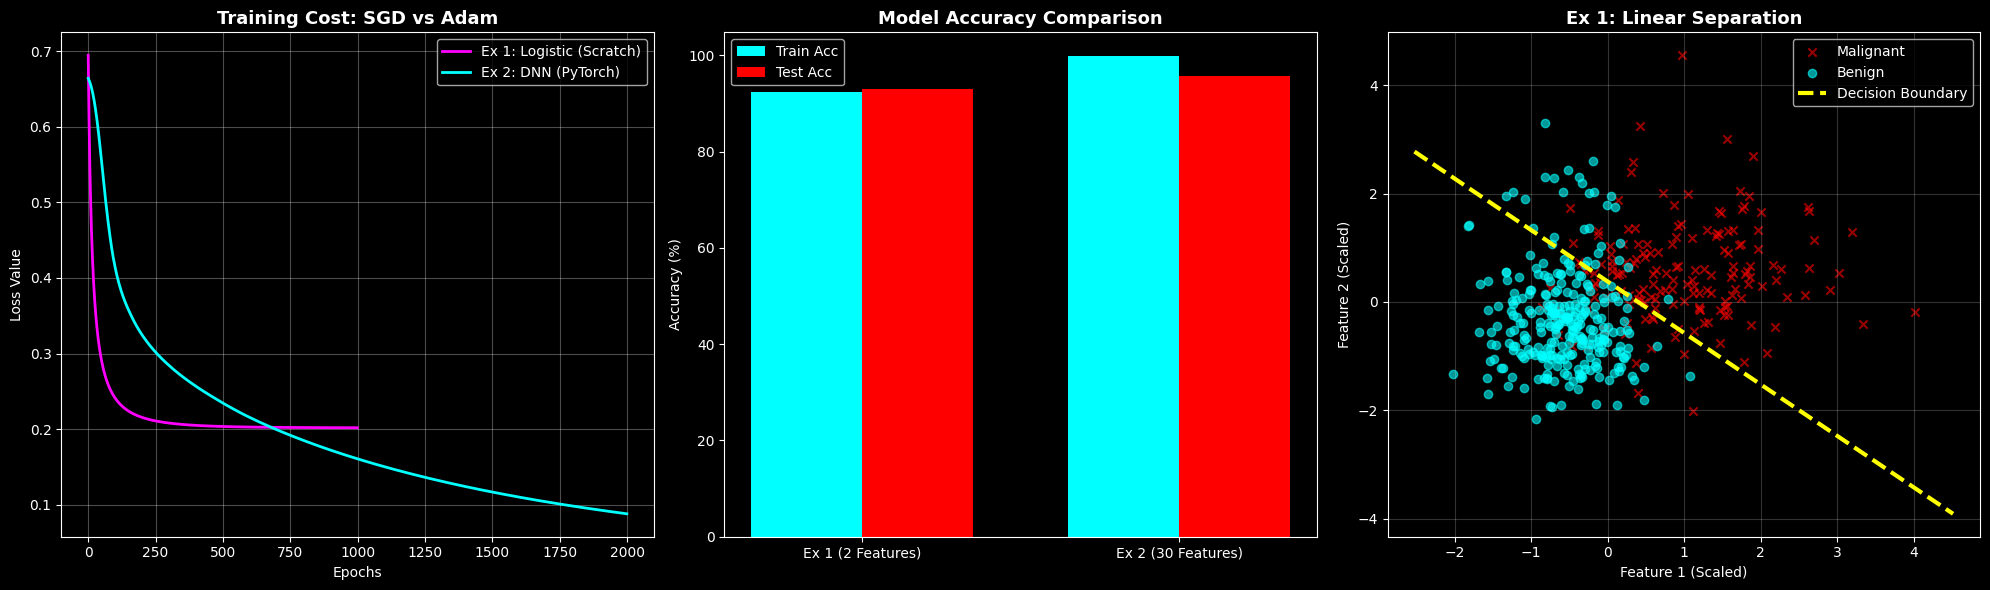

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6), dpi=100)

# 1. Training cost curves (Exercise 1 vs Exercise 2)
ax1.plot(range(len(cost_ex1)), cost_ex1, color='magenta', linewidth=2, label='Ex 1: Logistic (Scratch)')
ax1.plot(range(len(cost_ex2)), cost_ex2, color='cyan', linewidth=2, label='Ex 2: DNN (PyTorch)')
ax1.set_title('Training Cost: SGD vs Adam', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Accuracy comparison bar chart

labels = ['Ex 1 (2 Features)', 'Ex 2 (30 Features)']
train_accs = [train_acc_ex1, train_acc_ex2]
test_accs = [test_acc_ex1, test_acc_ex2]

x = np.arange(len(labels))
width = 0.35

ax2.bar(x - width/2, train_accs, width, label='Train Acc', color='cyan')
ax2.bar(x + width/2, test_accs, width, label='Test Acc', color='red')

ax2.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

# 3. Exercise 1 decision boundary (2D plot)

ax3.scatter(X_train_scaled[y_train == 0, 0], X_train_scaled[y_train == 0, 1],
            c='red', marker='x', label='Malignant', alpha=0.6)
ax3.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1],
            c='cyan', marker='o', label='Benign', alpha=0.6)

x1_vals = np.linspace(X_train_scaled[:, 0].min()-0.5, X_train_scaled[:, 0].max()+0.5, 100)
x2_vals = -(w1_logistic * x1_vals + b_logistic) / w2_logistic

ax3.plot(x1_vals, x2_vals, color='yellow', linewidth=3, linestyle='--', label='Decision Boundary')
ax3.set_title('Ex 1: Linear Separation', fontsize=13, fontweight='bold')
ax3.set_xlabel('Feature 1 (Scaled)')
ax3.set_ylabel('Feature 2 (Scaled)')
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()